In [ ]:
import pandas as pd

df =pd.read_csv('../data/raw/github_issues.csv')
print(df.columns)

kolom_pilihan = ['number', 'title', 'state', 'created_at', 'closed_at', 'labels']
df = df[kolom_pilihan]

df['created_at'] = pd.to_datetime(df['created_at'])
df['closed_at'] = pd.to_datetime(df['closed_at'])

df['duration_days'] = (df['closed_at'] - df['created_at']).dt.total_seconds() / 86400

df = df.dropna(subset=['closed_at'])

df.to_csv('../data/clean/database_final.csv', index=False)

In [ ]:
import pandas as pd
import os

BASE_DIR = r'C:\Users\lenovo\Desktop\GitHub\Stat\Project-Statistika-Kelompok-11'
RAW_FOLDER = os.path.join(BASE_DIR, 'data', 'raw')
CLEAN_FOLDER = os.path.join(BASE_DIR, 'data', 'clean')
os.makedirs(CLEAN_FOLDER, exist_ok=True)

print("🔄 Memuat data mentah...")
df_iss_raw = pd.read_csv(os.path.join(RAW_FOLDER, 'pandas_issues_raw.csv'))
df_prs_raw = pd.read_csv(os.path.join(RAW_FOLDER, 'pandas_prs_raw.csv'))

df_issues = df_iss_raw[df_iss_raw['pull_request'].isna()].copy()
df_issues['type'] = 'ISSUE'

df_prs_merged = df_prs_raw[df_prs_raw['merged_at'].notna()].copy()
df_prs_merged['type'] = 'PR'

df_combined = pd.concat([df_issues, df_prs_merged], ignore_index=True)

df_combined['created_at'] = pd.to_datetime(df_combined['created_at'], errors='coerce')
df_combined['closed_at'] = pd.to_datetime(df_combined['closed_at'], errors='coerce')

df_combined['duration_days'] = ((df_combined['closed_at'] - df_combined['created_at']).dt.total_seconds() / 86400).round(2)

df_combined['labels'] = df_combined['labels'].astype(str)
df_combined['is_bug'] = df_combined['labels'].str.lower().str.contains('bug', na=False).astype(int)

final_cols = ['number', 'type', 'is_bug', 'duration_days', 'created_at', 'closed_at']
df_final = df_combined[final_cols].drop_duplicates(subset=['number', 'type'])

df_final.to_csv(os.path.join(CLEAN_FOLDER, 'dataset_final.csv'), index=False)

print("\n" + "="*30)
print("✅ CLEANING SELESAI!")
print(f"📊 Issues: {len(df_issues)}")
print(f"📊 Merged PRs: {len(df_prs_merged)}")
print(f"💾 Disimpan ke: {os.path.join(CLEAN_FOLDER, 'dataset_final.csv')}")
print("="*30)

🔄 Memuat data mentah...

✅ CLEANING SELESAI!
📊 Issues: 1311
📊 Merged PRs: 1112
💾 Disimpan ke: C:\Users\lenovo\Desktop\GitHub\Stat\Project-Statistika-Kelompok-11\data\clean\dataset_final.csv


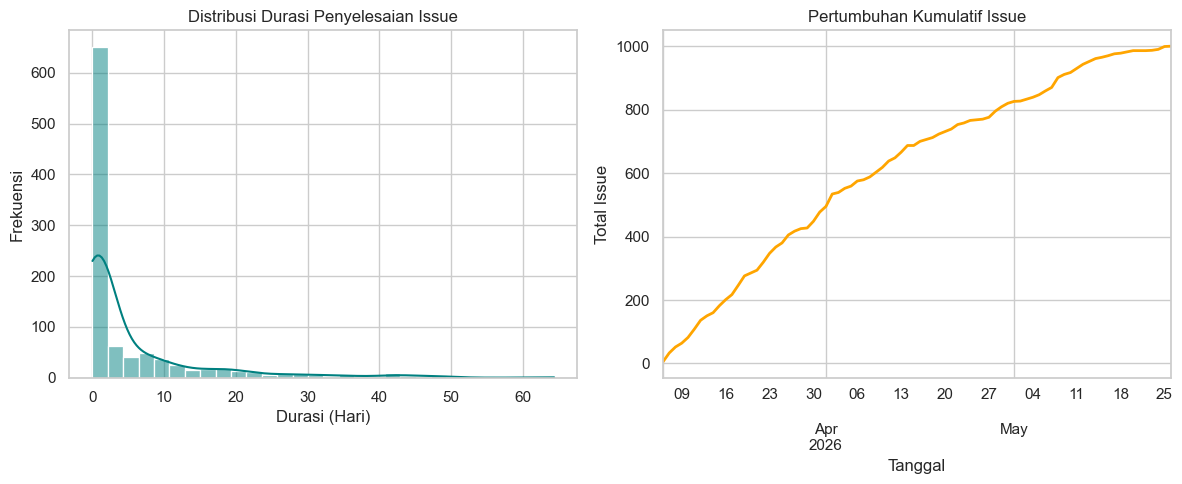

------------------------------
STATISTIK DESKRIPTIF UNTUK MEMBER B:
count    1000.000000
mean        5.345638
std         9.597467
min         0.000150
25%         0.277717
50%         0.935816
75%         6.240301
max        64.343866
Name: duration_days, dtype: float64
------------------------------


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# GRAFIK 1: Distribusi Waktu Penyelesaian (Histogram)
plt.subplot(1, 2, 1)
sns.histplot(df_clean['duration_days'], bins=30, kde=True, color='teal')
plt.title('Distribusi Durasi Penyelesaian Issue', fontsize=12)
plt.xlabel('Durasi (Hari)')
plt.ylabel('Frekuensi')

# GRAFIK 2: Tren Kumulatif Issue Dibuat (Time Series)
plt.subplot(1, 2, 2) # Grafik kanan
df_clean.set_index('created_at').resample('D').size().cumsum().plot(color='orange', lw=2)
plt.title('Pertumbuhan Kumulatif Issue', fontsize=12)
plt.xlabel('Tanggal')
plt.ylabel('Total Issue')

plt.tight_layout()
plt.show()

print("-" * 30)
print("STATISTIK DESKRIPTIF UNTUK MEMBER B:")
print(df_clean['duration_days'].describe())
print("-" * 30)